# Random Embeddings and the Cycle Double Cover Conjecture

This notebook explores random embeddings of bridgeless cubic graphs using the $(\pi, \lambda)$ model, with the goal of gaining insight into the Cycle Double Cover (CDC) conjecture.

We generate random embeddings and analyze their facial structure by counting:
- **good singular links (−)**
- **bad singular links (+)**
- **regular links**

A central question is whether, for a graph with $m$ edges, these quantities are roughly equal in expectation:
$$
\text{good} \approx \text{bad} \approx \text{regular} \approx \frac{m}{3}
$$

Understanding this distribution helps assess how far random embeddings are from having no singular edges, which would correspond to a cycle double cover.

---

## Notation

Each output is a triple of the form:

`[good singular (-), bad singular (+), regular]`


- A **good singular link (−)** means the same oriented edge appears twice in a single facial walk  
- A **bad singular link (+)** means the edge appears twice with opposite orientations  
- A **regular link** means the edge appears in two different faces


In [2]:
import random
import numpy as np


# ============================================================
# Edge occurrences in the embedding
# ============================================================

def edge_occurrences(G):
    """
    Create the list of edge occurrences.

    E[0] = None because Sage permutations are 1-indexed.

    Each edge occurrence has form:

        (v, w, s)

    where:
        v -> w is an oriented copy of an edge,
        s is 0 or 1.
    """
    E = [None]

    for v in G.vertices():
        for w in G.neighbors(v):
            for s in [0, 1]:
                E.append((v, w, s))

    return E


def edge_occurrence_index(E):
    """
    Fast lookup dictionary:

        (v, w, s) -> index in E
    """
    return {E[i]: i for i in range(1, len(E))}


def underlying_edge(e):
    """
    Convert an oriented edge (u,v) to an unoriented edge.
    """
    u, v = e
    return tuple(sorted((u, v)))


def reverse_edge(e):
    """
    Reverse an oriented edge.
    """
    u, v = e
    return (v, u)


def average(values):
    """
    Average using NumPy.
    """
    return np.mean(values)


# ============================================================
# Random embedding: (pi, lambda)
# ============================================================

def random_pi(G, I):
    """
    Construct the vertex rotation permutation pi.

    Around each vertex, choose a random cyclic order of neighbors.
    """
    pi_cycles = []

    for v in G.vertices():
        N = list(G.neighbors(v))
        random.shuffle(N)

        for x, y in zip(N, N[1:] + [N[0]]):
            pi_cycles.append((
                I[(v, x, 1)],
                I[(v, y, 0)]
            ))

    return Permutation(pi_cycles)


def random_lambda(G, I, do_twist=True):
    """
    Construct the edge-sign permutation lambda.

    If do_twist=True, each edge receives a random twist.
    If do_twist=False, all edges use the same untwisted choice.
    """
    lambda_cycles = []

    for u, v in G.edges(labels=False):
        t = random.randint(0, 1) if do_twist else 1

        lambda_cycles.append((
            I[(u, v, 0)],
            I[(v, u, t)]
        ))

        lambda_cycles.append((
            I[(u, v, 1)],
            I[(v, u, (t + 1) % 2)]
        ))

    return Permutation(lambda_cycles)


def random_embedding(G, do_twist=True, return_data=False):
    """
    Construct a random embedding (pi, lambda).

    The facial permutation is:

        phi = pi * lambda

    The cycles of phi are the facial walks.
    """
    E = edge_occurrences(G)
    I = edge_occurrence_index(E)

    pi = random_pi(G, I)
    lam = random_lambda(G, I, do_twist=do_twist)

    phi = pi * lam

    if return_data:
        return phi, pi, lam, E

    return phi


# ============================================================
# Facial walks
# ============================================================

def facial_walks_as_edge_occurrences(G, do_twist=True):
    """
    Return facial walks as cycles of edge-occurrence indices.
    """
    phi = random_embedding(G, do_twist=do_twist)
    return phi.cycle_tuples()


def facial_walks_as_edges(G, do_twist=True):
    """
    Return facial walks as unoriented graph edges.
    """
    phi, pi, lam, E = random_embedding(
        G,
        do_twist=do_twist,
        return_data=True
    )

    walks = []

    for face in phi.cycle_tuples():
        F = []

        for i in face:
            v, w, s = E[i]
            F.append(underlying_edge((v, w)))

        walks.append(F)

    return walks


def facial_walks_as_oriented_edges(G, do_twist=True):
    """
    Return facial walks as oriented edge occurrences.

    Each occurrence is:

        (u, v)

    meaning the edge is traversed from u to v.
    """
    phi, pi, lam, E = random_embedding(
        G,
        do_twist=do_twist,
        return_data=True
    )

    walks = []

    for face in phi.cycle_tuples():
        F = []

        for i in face:
            v, w, s = E[i]
            F.append((v, w))

        walks.append(F)

    return walks


def number_of_faces(G, do_twist=True):
    """
    Return the number of facial walks.

    Because this model has two parallel copies of each facial walk,
    we divide by 2.
    """
    phi = random_embedding(G, do_twist=do_twist)
    return len(phi.cycle_tuples()) / 2


def sample_number_of_faces(G, samples=10, do_twist=True):
    """
    Sample the number of facial walks.
    """
    return [
        number_of_faces(G, do_twist=do_twist)
        for _ in range(samples)
    ]


# ============================================================
# Singular and regular links in facial-diagram notation
# ============================================================

def count_good_bad_regular(G, do_twist=True):
    """
    Return:

        [good_singular, bad_singular, regular]

    In the facial-diagram notation:

        sign '-' = good singular link
                 = same oriented edge appears twice in one face

        sign '+' = bad singular link
                 = opposite orientations appear in one face

        regular  = edge appears in two different faces

    The edge-occurrence model counts singular links twice,
    so singular counts are divided by 2.
    """
    faces = facial_walks_as_oriented_edges(G, do_twist=do_twist)

    good_singular = 0
    bad_singular = 0

    for F in faces:
        for i in range(len(F)):
            for j in range(i + 1, len(F)):
                e = F[i]
                f = F[j]

                if e == f:
                    good_singular += 1

                elif e == reverse_edge(f):
                    bad_singular += 1

    good_singular = good_singular / 2
    bad_singular = bad_singular / 2

    regular = G.num_edges() - good_singular - bad_singular

    return [good_singular, bad_singular, regular]


def count_singular(G, do_twist=True):
    """
    Return the total number of singular links.
    """
    good, bad, regular = count_good_bad_regular(
        G,
        do_twist=do_twist
    )

    return good + bad


def sample_good_bad_regular(G, samples=10, do_twist=True):
    """
    Sample:

        [good singular, bad singular, regular]
    """
    return [
        count_good_bad_regular(G, do_twist=do_twist)
        for _ in range(samples)
    ]


def expected_good_bad_regular(G, samples=100, do_twist=True):
    """
    Estimate expected values of:

        good singular links,
        bad singular links,
        regular links.
    """
    values = sample_good_bad_regular(
        G,
        samples=samples,
        do_twist=do_twist
    )

    good_values = [x[0] for x in values]
    bad_values = [x[1] for x in values]
    regular_values = [x[2] for x in values]

    return [
        average(good_values),
        average(bad_values),
        average(regular_values)
    ]


# ============================================================
# Facial diagram data
# ============================================================

def facial_diagram_data(G, do_twist=True):
    """
    Return a dictionary describing the facial diagram H.

    Output keys:

        "faces":
            facial walks as oriented edges

        "good_singular_links":
            singular links with sign '-'

        "bad_singular_links":
            singular links with sign '+'

        "regular_count":
            number of regular links
    """
    faces = facial_walks_as_oriented_edges(G, do_twist=do_twist)

    good_links = []
    bad_links = []

    for face_id, F in enumerate(faces):
        for i in range(len(F)):
            for j in range(i + 1, len(F)):
                e = F[i]
                f = F[j]

                if e == f:
                    good_links.append({
                        "edge": underlying_edge(e),
                        "face": face_id,
                        "positions": (i, j),
                        "sign": "-"
                    })

                elif e == reverse_edge(f):
                    bad_links.append({
                        "edge": underlying_edge(e),
                        "face": face_id,
                        "positions": (i, j),
                        "sign": "+"
                    })

    good_count = len(good_links) / 2
    bad_count = len(bad_links) / 2
    regular_count = G.num_edges() - good_count - bad_count

    return {
        "faces": faces,
        "good_singular_links": good_links,
        "bad_singular_links": bad_links,
        "good_count": good_count,
        "bad_count": bad_count,
        "regular_count": regular_count
    }


# ============================================================
# Crossing singular links
# ============================================================

def are_crossing(pos1, pos2):
    """
    Two singular links cross if their endpoints alternate:

        e1, e2, e1, e2
    """
    a, b = sorted(pos1)
    c, d = sorted(pos2)

    return (a < c < b < d) or (c < a < d < b)


def crossing_singular_links(G, do_twist=True):
    """
    Return crossing pairs of singular links.
    """
    H = facial_diagram_data(G, do_twist=do_twist)

    singular_links = (
        H["good_singular_links"] +
        H["bad_singular_links"]
    )

    crossings = []

    for i in range(len(singular_links)):
        for j in range(i + 1, len(singular_links)):
            L1 = singular_links[i]
            L2 = singular_links[j]

            if L1["face"] == L2["face"]:
                if are_crossing(L1["positions"], L2["positions"]):
                    crossings.append((L1, L2))

    return crossings


# ============================================================
# CDC-related sampling
# ============================================================

def has_no_singular_links(G, do_twist=True):
    """
    Return True if this sampled embedding has no singular links.
    """
    return count_singular(G, do_twist=do_twist) == 0


def number_of_CDC_samples(G, samples=100, do_twist=True):
    """
    Count how many sampled embeddings have no singular links.
    """
    count = 0

    for _ in range(samples):
        if has_no_singular_links(G, do_twist=do_twist):
            count += 1

    return count# Random Embeddings and the Cycle Double Cover Conjecture




def sample_singular_counts(G, samples=100, do_twist=True):
    """
    Sample total number of singular links.
    """
    return [
        count_singular(G, do_twist=do_twist)
        for _ in range(samples)
    ]


# ============================================================
# Plot
# ============================================================

def diagram_good_bad_regular(G, samples=100, do_twist=True):
    """
    Plot sampled points:

        x-axis = good singular links, sign '-'
        y-axis = bad singular links, sign '+'
    """
    m = G.num_edges()

    values = sample_good_bad_regular(
        G,
        samples=samples,
        do_twist=do_twist
    )

    red_points = [(x[0], x[1]) for x in values if x[1] != 0]
    black_points = [(x[0], x[1]) for x in values if x[1] == 0]

    P = line([(m, 0), (0, m), (0, 0), (m, 0)])
    P += points(red_points, color="red", size=40)
    P += points(black_points, color="black", size=50)

    return P

In [5]:
# ------------------------------------------------------------
# Petersen graph
# ------------------------------------------------------------

print("----- Petersen Graph -----")

G = graphs.PetersenGraph()

print("Sample [good singular, bad singular, regular]:")
print(sample_good_bad_regular(G, samples=7, do_twist=True))

----- Petersen Graph -----
Sample [good singular, bad singular, regular]:
[[4, 5, 6], [10, 5, 0], [6, 9, 0], [1, 4, 10], [4, 3, 8], [2, 3, 10], [8, 7, 0]]


In [6]:
print("Single sample (only singular counts):")
print(count_good_bad_regular(G, do_twist=True)[:2])


Single sample (only singular counts):
[1, 3]


In [7]:
print("Expected values:")
print(expected_good_bad_regular(G, samples=100, do_twist=True))

Expected values:
[4.9, 4.71, 5.39]


In [8]:
print("Number of faces:")
print(number_of_faces(G))

Number of faces:
2


In [9]:
print("Sample number of faces:")
print(sample_number_of_faces(G, samples=20))

Sample number of faces:
[4, 3, 1, 2, 1, 1, 3, 1, 3, 1, 2, 1, 2, 1, 2, 3, 2, 1, 1, 1]


In [10]:
print("Total singular links:")
print(count_singular(G))

Total singular links:
6


In [11]:
print("Sample total singular links:")
print(sample_singular_counts(G, samples=20))

Sample total singular links:
[15, 15, 9, 4, 4, 10, 5, 15, 10, 7, 4, 3, 15, 6, 7, 7, 15, 10, 10, 6]


In [12]:
print("Number of CDC samples:")
print(number_of_CDC_samples(G, samples=100))

Number of CDC samples:
2


In [13]:
print("Crossing singular links:")
print(crossing_singular_links(G))

Crossing singular links:
[({'edge': (4, 9), 'face': 1, 'positions': (5, 10), 'sign': '-'}, {'edge': (7, 9), 'face': 1, 'positions': (6, 19), 'sign': '-'}), ({'edge': (4, 9), 'face': 1, 'positions': (5, 10), 'sign': '-'}, {'edge': (0, 5), 'face': 1, 'positions': (1, 8), 'sign': '+'}), ({'edge': (4, 9), 'face': 1, 'positions': (5, 10), 'sign': '-'}, {'edge': (5, 7), 'face': 1, 'positions': (7, 14), 'sign': '+'}), ({'edge': (7, 9), 'face': 1, 'positions': (6, 19), 'sign': '-'}, {'edge': (2, 7), 'face': 1, 'positions': (15, 20), 'sign': '-'}), ({'edge': (7, 9), 'face': 1, 'positions': (6, 19), 'sign': '-'}, {'edge': (0, 5), 'face': 1, 'positions': (1, 8), 'sign': '+'}), ({'edge': (7, 9), 'face': 1, 'positions': (6, 19), 'sign': '-'}, {'edge': (5, 8), 'face': 1, 'positions': (2, 13), 'sign': '+'}), ({'edge': (7, 9), 'face': 1, 'positions': (6, 19), 'sign': '-'}, {'edge': (6, 8), 'face': 1, 'positions': (12, 23), 'sign': '+'}), ({'edge': (7, 9), 'face': 1, 'positions': (6, 19), 'sign': '-'},

Facial diagram plot:


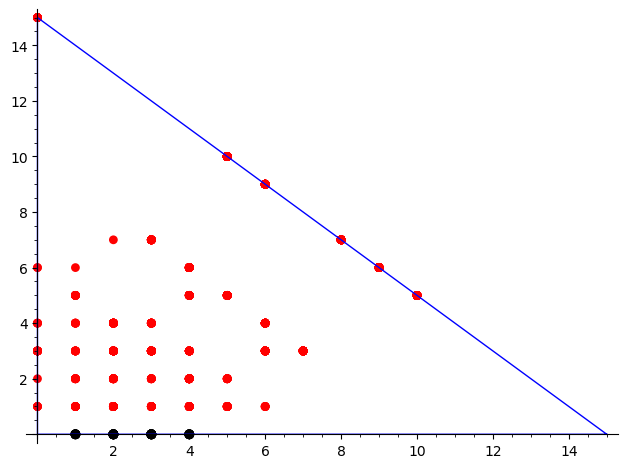

In [14]:
print("Facial diagram plot:")
show(diagram_good_bad_regular(G, samples=1000))

## Petersen graph experiment

For the Petersen graph, the sampled triples show noticeable variation between random embeddings.

The expected values are:

[4.9, 4.71, 5.39]


These values are fairly close to each other, suggesting that good singular links, bad singular links, and regular links appear in comparable amounts for this graph.

The number of faces also varies across samples, which shows that changing the random embedding can significantly change the facial structure.

In this run, 2 out of 100 sampled embeddings had no singular links, so CDC-type embeddings can appear randomly, but they are rare.

The facial diagram plot shows the sampled embeddings in the plane where:
- the x-axis is the number of good singular links
- the y-axis is the number of bad singular links


- **Red points** represent embeddings with at least one bad singular link  
- **Black points** represent embeddings with no bad singular links (only − links)

Black points are particularly important: when all singular links are negative, repeated twisting of these links reduces the number of singular edges. This process leads to an embedding with no singular links, i.e., a cycle double cover.

Most points lie away from the horizontal axis, meaning that typical random embeddings contain bad singular links, and therefore require more structure (not just direct reduction) to reach a CDC.

In [15]:
# ------------------------------------------------------------
# Complete graph K4
# ------------------------------------------------------------

print("\n\n----- Complete Graph K4 -----")

K4 = graphs.CompleteGraph(4)

print(sample_good_bad_regular(K4, samples=100))



----- Complete Graph K4 -----
[[4, 2, 0], [1, 1, 4], [1, 0, 5], [1, 1, 4], [1, 1, 4], [1, 0, 5], [1, 1, 4], [3, 3, 0], [4, 2, 0], [1, 0, 5], [4, 2, 0], [1, 0, 5], [1, 1, 4], [3, 3, 0], [3, 3, 0], [3, 3, 0], [0, 2, 4], [2, 0, 4], [2, 1, 3], [3, 3, 0], [2, 1, 3], [2, 1, 3], [3, 3, 0], [0, 3, 3], [1, 0, 5], [4, 2, 0], [0, 2, 4], [1, 0, 5], [3, 3, 0], [1, 1, 4], [2, 1, 3], [3, 3, 0], [0, 3, 3], [3, 3, 0], [1, 0, 5], [3, 3, 0], [3, 3, 0], [3, 3, 0], [1, 1, 4], [3, 3, 0], [3, 3, 0], [2, 1, 3], [3, 3, 0], [1, 1, 4], [2, 1, 3], [0, 3, 3], [3, 3, 0], [2, 1, 3], [3, 3, 0], [4, 2, 0], [1, 0, 5], [2, 1, 3], [1, 0, 5], [2, 1, 3], [4, 2, 0], [1, 0, 5], [2, 1, 3], [4, 2, 0], [1, 0, 5], [3, 3, 0], [3, 3, 0], [4, 2, 0], [4, 2, 0], [4, 2, 0], [2, 0, 4], [3, 3, 0], [1, 0, 5], [3, 3, 0], [3, 3, 0], [4, 2, 0], [4, 2, 0], [3, 3, 0], [0, 2, 4], [2, 1, 3], [4, 2, 0], [3, 3, 0], [2, 1, 3], [3, 3, 0], [3, 3, 0], [0, 2, 4], [3, 3, 0], [3, 3, 0], [3, 3, 0], [1, 1, 4], [1, 1, 4], [0, 2, 4], [2, 1, 3], [0, 0, 6],

In [16]:
print(expected_good_bad_regular(K4, samples=100))

[2.3, 1.82, 1.88]


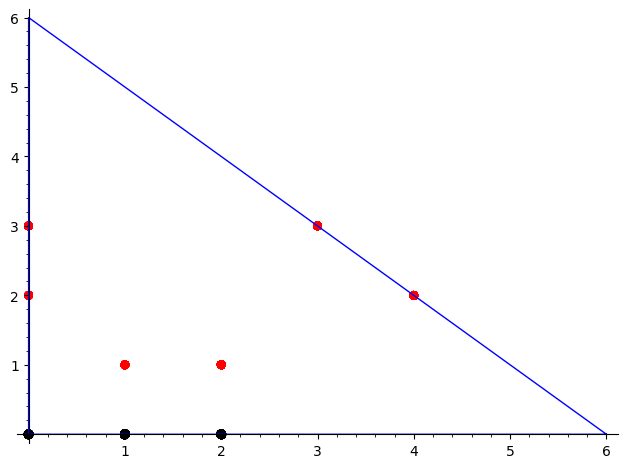

In [17]:
show(diagram_good_bad_regular(K4, samples=1000))

## Complete graph \(K_4\) experiment

For \(K_4\), the sampled triples show that the possible values are much more limited than in the Petersen graph.

The expected values are approximately:
(2.3, 1.82, 1.88)

Since \(K_4\) has only 6 edges, the scatter plot lies inside a small triangular region, reflecting the constraint that all edges are partitioned into the three types.

Compared to larger graphs, black points appear more frequently in \(K_4\), indicating that simpler graphs are closer to having a cycle double cover under random embeddings.

In [18]:
# ------------------------------------------------------------
# Flower snark
# ------------------------------------------------------------

print("\n\n----- Flower Snark -----")

FL = graphs.FlowerSnark()

print(expected_good_bad_regular(FL, samples=100))



----- Flower Snark -----
[9.96, 9.76, 10.28]


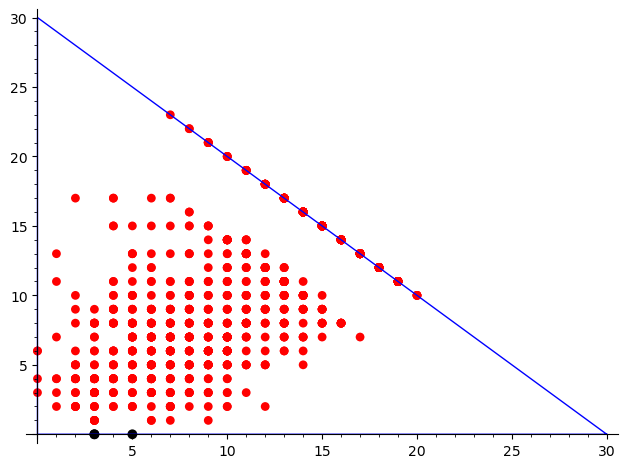

In [19]:
show(diagram_good_bad_regular(FL, samples=1000))

## Flower snark experiment

For the Flower snark, the expected values are approximately:
(9.96, 9.76, 10.28)

The three values are very close, suggesting that good singular links, bad singular links, and regular links occur in nearly equal proportions for this graph.

The scatter plot is much denser than in the smaller examples, and most samples contain both good and bad singular links. Only a few points lie on the horizontal axis, so embeddings with no bad singular links are rare.

This indicates that for the Flower snark, random embeddings are usually not immediately reducible to a cycle double cover by only twisting negative links. More structure or additional twist strategy is needed.

In [20]:
# ------------------------------------------------------------
# Blanuša snarks
# ------------------------------------------------------------

print("\n\n----- Blanusa Snarks -----")

B1 = graphs.BlanusaFirstSnarkGraph()
B2 = graphs.BlanusaSecondSnarkGraph()

print("Blanusa 1 expectation:")
print(expected_good_bad_regular(B1, samples=100))



----- Blanusa Snarks -----
Blanusa 1 expectation:
[9.43, 8.31, 9.26]


In [21]:
print("Blanusa 2 expectation:")
print(expected_good_bad_regular(B2, samples=100))

Blanusa 2 expectation:
[10.18, 8.83, 7.99]


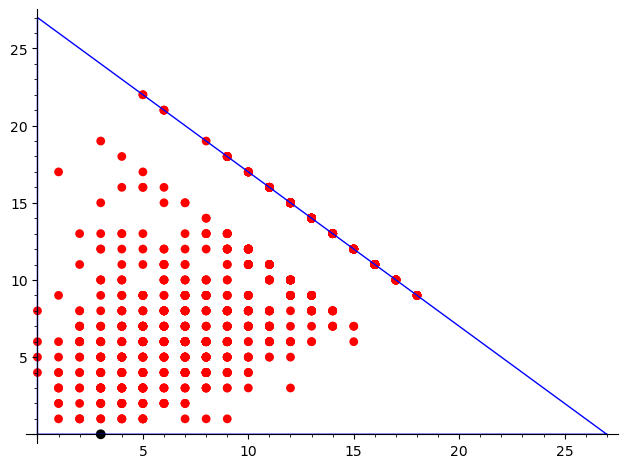

In [22]:
show(diagram_good_bad_regular(B1, samples=1000))

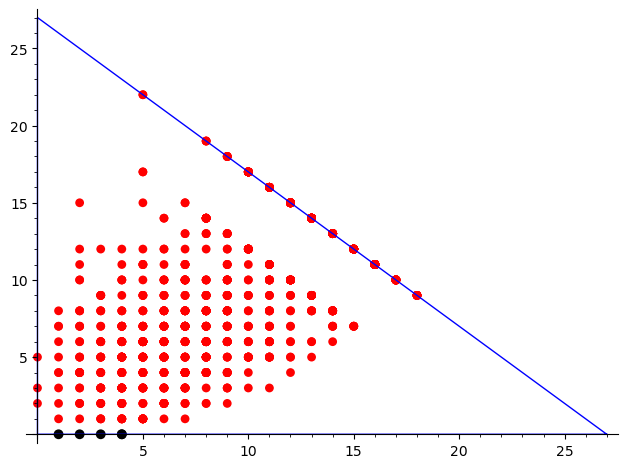

In [23]:
show(diagram_good_bad_regular(B2, samples=1000))

In [24]:
L = sample_good_bad_regular(B2, samples=1000)

print("\nSamples with no bad singular links (+):")
print(len([x for x in L if x[1] == 0]))


Samples with no bad singular links (+):
7


In [25]:
print("Samples with no good singular links (-):")
print(len([x for x in L if x[0] == 0]))

Samples with no good singular links (-):
4


## Blanuša snarks experiment

For the two Blanuša snarks, the expected values are:

Blanuša 1:
(9.43, 8.31, 9.26)

Blanuša 2:
(10.18, 8.83, 7.99)

Both graphs show a similar distribution pattern. Most random embeddings contain a mixture of good singular links, bad singular links, and regular links.

The scatter plots are concentrated away from the horizontal axis, meaning that embeddings with no bad singular links are uncommon. For Blanuša 2, only 7 out of 1000 samples had no bad singular links, while 4 out of 1000 had no good singular links.

This suggests that favorable embeddings still occur, but they are rare. Compared with smaller graphs such as \(K_4\), the Blanuša snarks are less likely to produce embeddings that can be directly reduced to a cycle double cover by twisting only negative links.



----- Random Cubic Graphs (small sizes) -----

Random cubic graph on 10 vertices
Expected values:
[5.35, 4.57, 5.08]


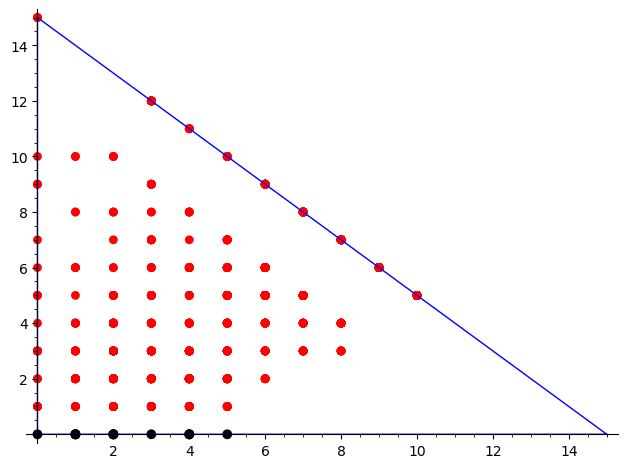


Random cubic graph on 20 vertices
Expected values:
[10.62, 10.09, 9.29]


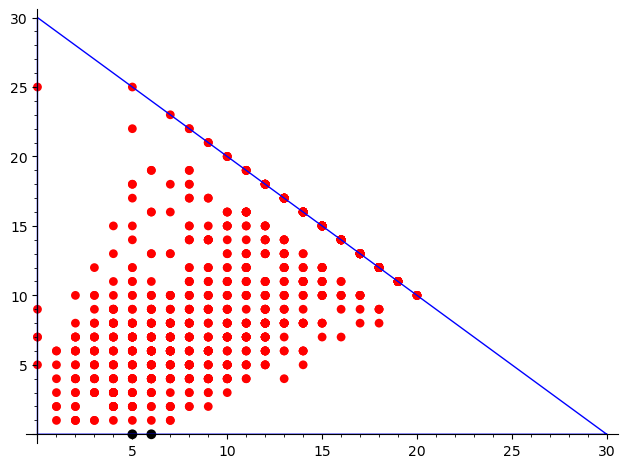


Random cubic graph on 26 vertices
Expected values:
[13.62, 13.28, 12.1]


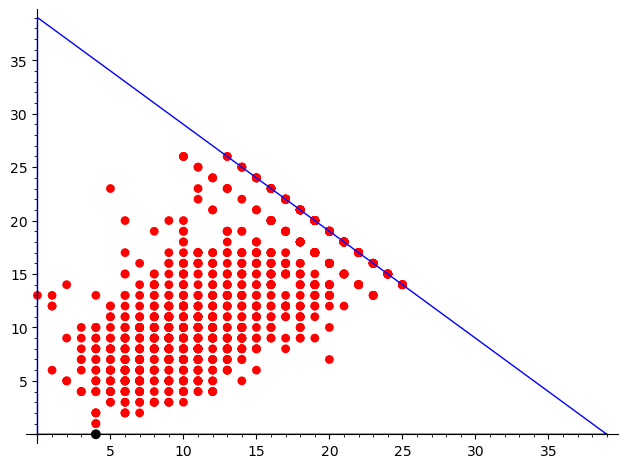


Random cubic graph on 30 vertices
Expected values:
[15.82, 15.27, 13.91]


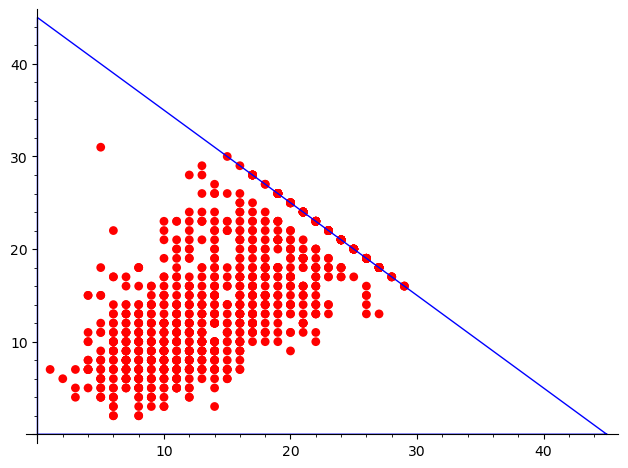


Random cubic graph on 40 vertices
Expected values:
[19.48, 19.45, 21.07]


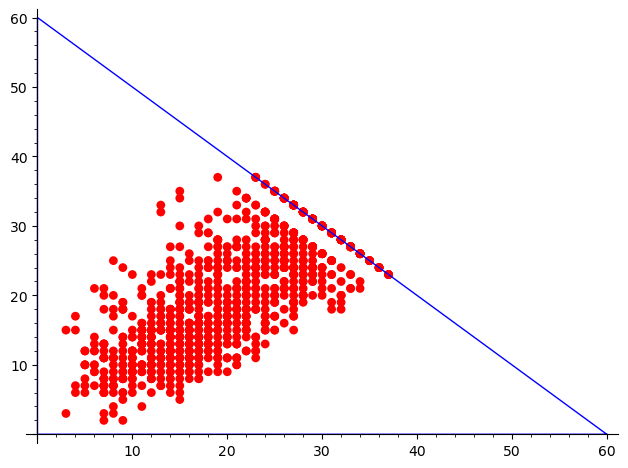

In [26]:
# ------------------------------------------------------------
# Random cubic graphs (small sizes)
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graphs (small sizes) -----")

sizes = [10, 20, 26, 30, 40]

for n in sizes:
    print(f"\nRandom cubic graph on {n} vertices")

    R = graphs.RandomRegular(3, n)

    print("Expected values:")
    print(expected_good_bad_regular(R, samples=100))

    show(diagram_good_bad_regular(R, samples=1000))


## Random cubic graphs (small sizes)

For random cubic graphs of increasing size, the expected values are:

- \(n = 10\): (5.35, 4.57, 5.08)  
- \(n = 20\): (10.62, 10.09, 9.29)  
- \(n = 26\): (13.62, 13.28, 12.10)  
- \(n = 30\): (15.82, 15.27, 13.91)  
- \(n = 40\): (19.48, 19.45, 21.07)  

As the number of vertices increases, all three quantities grow roughly linearly.

The scatter plots show a clear pattern: the points concentrate in a dense region away from the axes, and the cloud becomes more structured as the graph size increases.

This indicates that random embeddings consistently produce a balanced mixture of good singular, bad singular, and regular links. At the same time, embeddings with no bad singular links become increasingly rare, as seen from the scarcity of points on the horizontal axis.

Overall, larger random cubic graphs behave more predictably, with the distribution stabilizing and fluctuations becoming smaller relative to the size of the graph.



----- Random Cubic Graph on 50 vertices -----
[25.23, 24.1, 25.67]


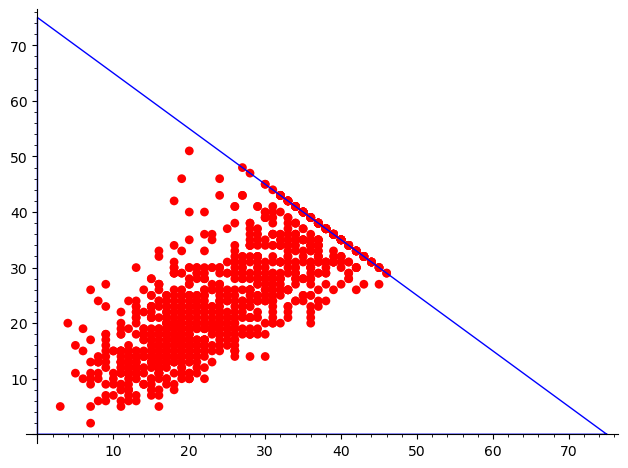

In [27]:
# ------------------------------------------------------------
# Random cubic graph on 50 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 50 vertices -----")

R50 = graphs.RandomRegular(3, 50)

print(expected_good_bad_regular(R50, samples=100))
show(diagram_good_bad_regular(R50, samples=1000))




----- Random Cubic Graph on 100 vertices -----
[46.77, 45.79, 57.44]

Samples with no bad singular links (+):
0


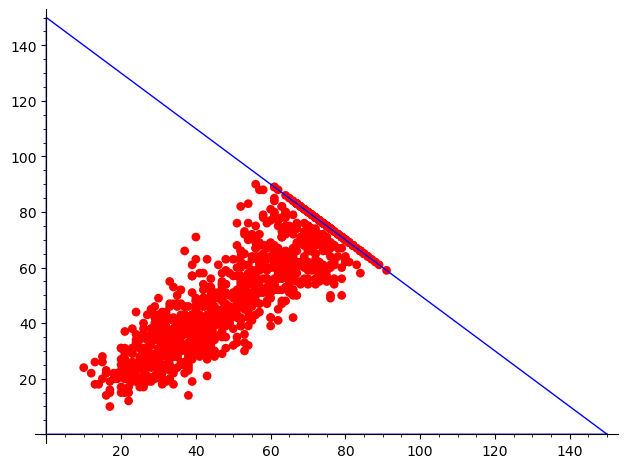

In [28]:
# ------------------------------------------------------------
# Random cubic graph on 100 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 100 vertices -----")

R100 = graphs.RandomRegular(3, 100)

print(expected_good_bad_regular(R100, samples=100))

L = sample_good_bad_regular(R100, samples=1000)

print("\nSamples with no bad singular links (+):")
print(len([x for x in L if x[1] == 0]))

show(diagram_good_bad_regular(R100, samples=1000))



----- Random Cubic Graph on 110 vertices -----
[56.97, 55.47, 52.56]


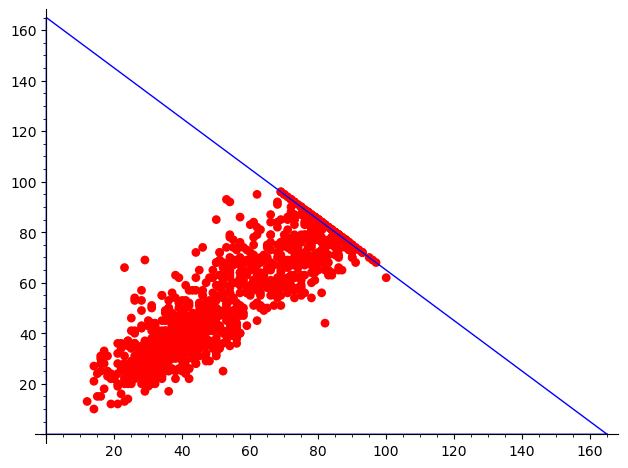

In [29]:
# ------------------------------------------------------------
# Random cubic graph on 110 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 110 vertices -----")

R110 = graphs.RandomRegular(3, 110)

print(expected_good_bad_regular(R110, samples=100))
show(diagram_good_bad_regular(R110, samples=1000))

## Random cubic graphs (larger sizes)

For larger random cubic graphs, the expected values are:

- \(n = 50\): (25.23, 24.10, 25.67)  
- \(n = 100\): (46.77, 45.79, 57.44)  
- \(n = 110\): (56.97, 55.47, 52.56)  

The scatter plots become more concentrated as the graph size increases. The samples form a clear cloud around the expected region instead of spreading across the whole triangle.

For \(n = 100\), none of the 1000 sampled embeddings had no bad singular links. This suggests that favorable embeddings become much harder to find by random sampling alone as the graph gets larger.

Overall, the larger examples support the idea that random embeddings have predictable average behavior, but they are usually far from directly producing a cycle double cover.

In [38]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_link_type_histograms(G, graph_name, samples=1000):
    L = sample_good_bad_regular(G, samples=samples)

    data = {
        "good singular links": [int(x[0]) for x in L],
        "bad singular links": [int(x[1]) for x in L],
        "regular links": [int(x[2]) for x in L],
    }

    for label, values in data.items():
        counts = Counter(values)
        xs = sorted(counts.keys())
        ys = [counts[x] for x in xs]

        plt.figure()
        plt.bar(xs, ys, edgecolor="black")

        plt.title(f"{graph_name} – {label}")
        plt.xlabel(f"number of {label}")
        plt.ylabel("frequency")
        plt.xticks(xs)

        plt.show()

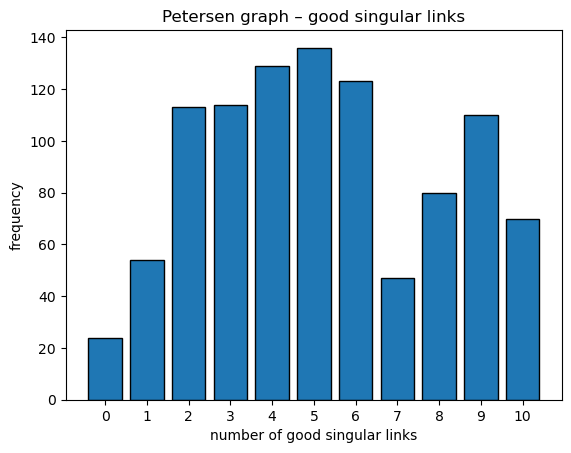

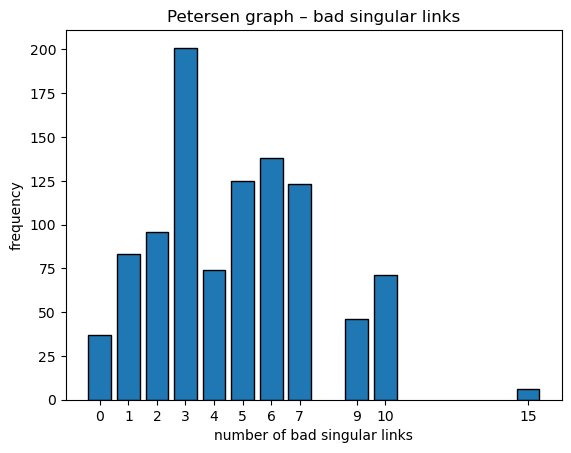

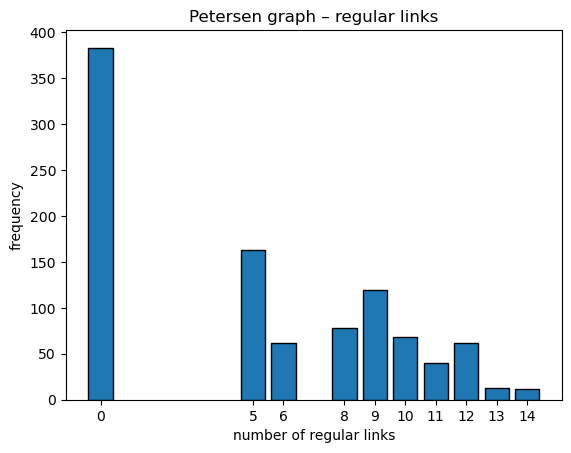

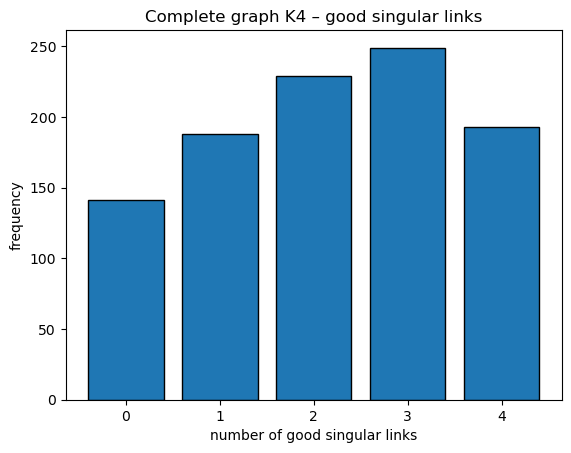

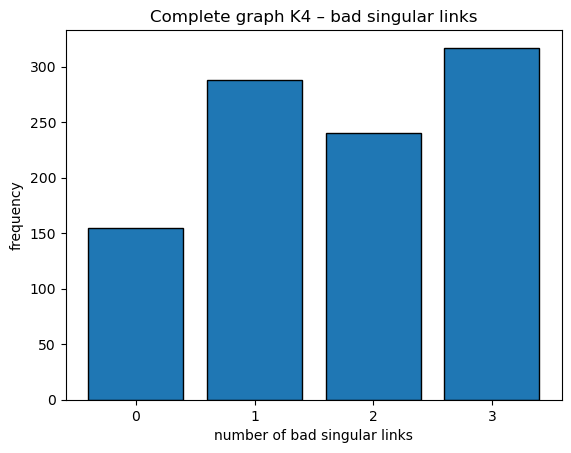

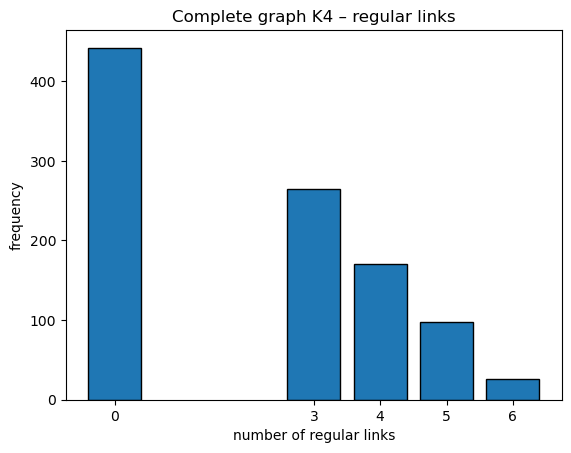

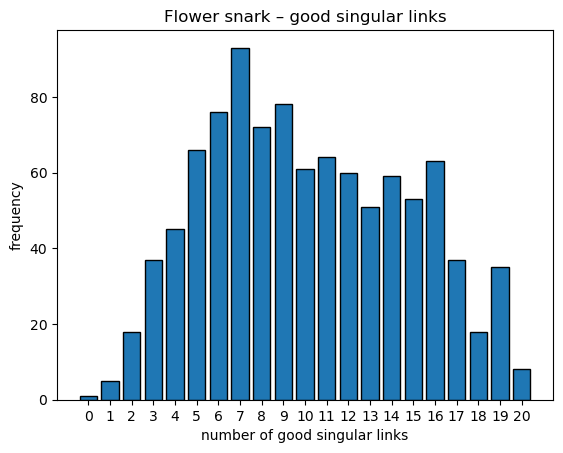

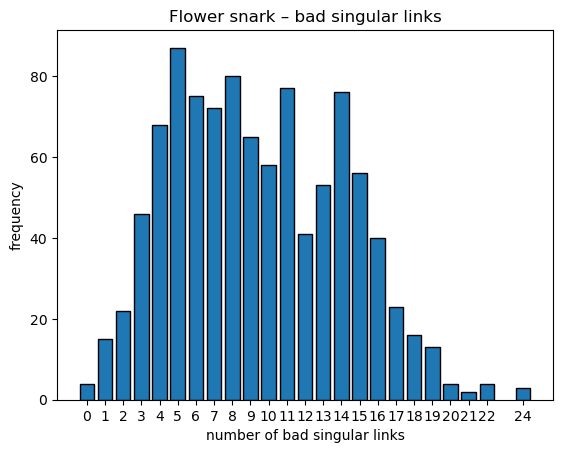

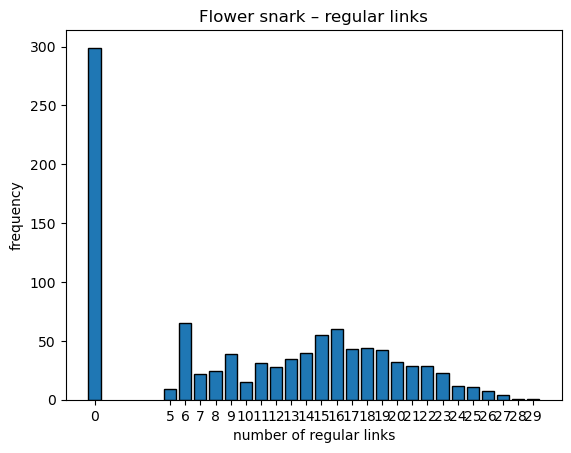

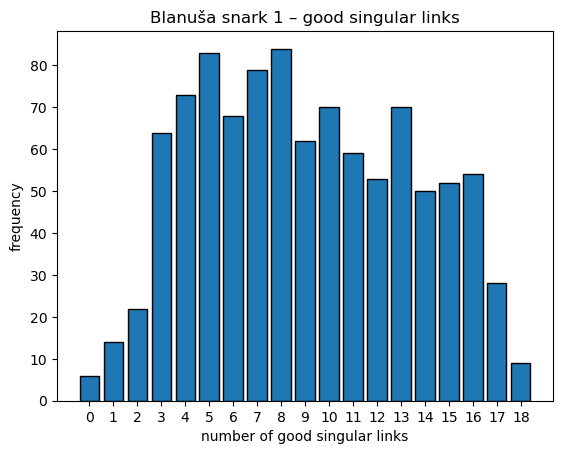

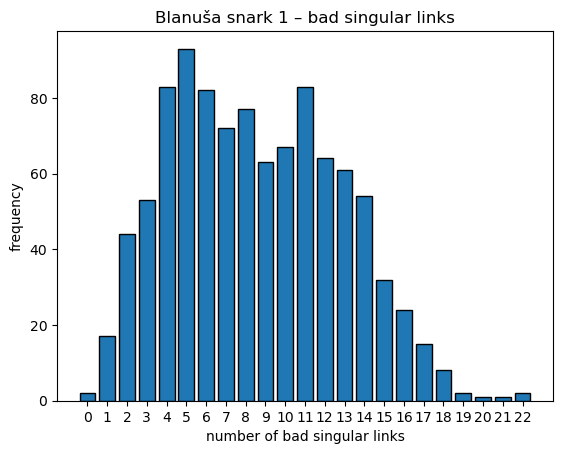

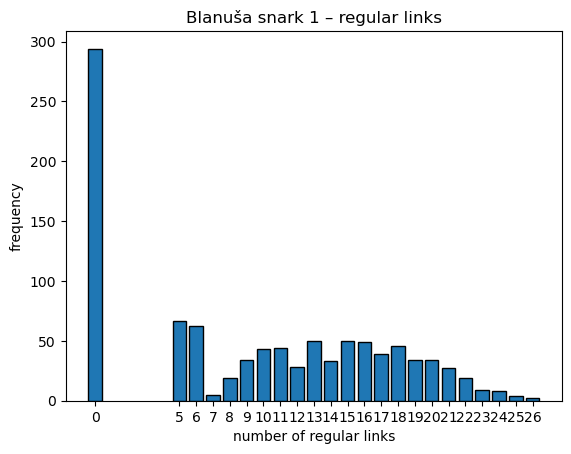

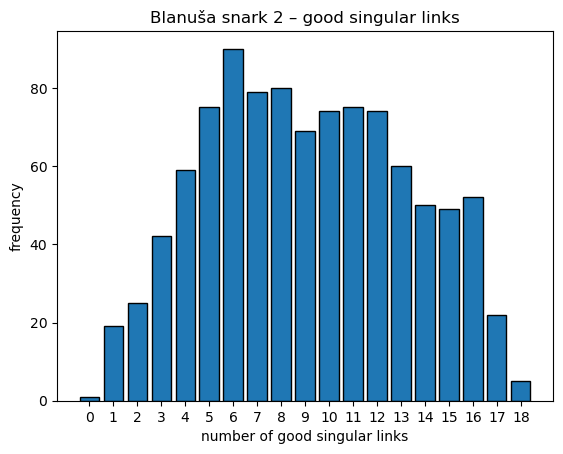

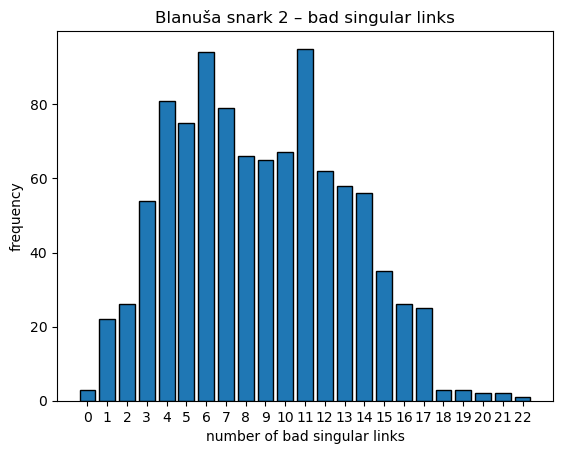

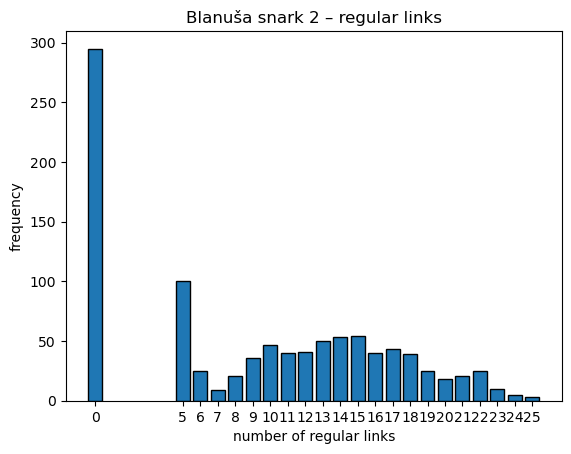

In [39]:
plot_link_type_histograms(graphs.PetersenGraph(), "Petersen graph")
plot_link_type_histograms(graphs.CompleteGraph(4), "Complete graph K4")
plot_link_type_histograms(graphs.FlowerSnark(), "Flower snark")
plot_link_type_histograms(graphs.BlanusaFirstSnarkGraph(), "Blanuša snark 1")
plot_link_type_histograms(graphs.BlanusaSecondSnarkGraph(), "Blanuša snark 2")

The histograms show the distribution of good singular links, bad singular links, and regular links over many random embeddings.

### Petersen graph

- Both good and bad singular links are spread over a range of values, with a clear concentration around the middle.
- The distribution is fairly symmetric, indicating no strong bias toward either type.
- The number of regular links shows a different pattern, with a noticeable peak at 0 and additional mass at higher values.
- This suggests that some embeddings have no regular links at all, while others distribute edges more evenly.

### Complete graph \(K_4\)

- The distributions are much tighter due to the small size of the graph.
- Only a few discrete values appear, and the frequencies are clearly separated.
- The regular links histogram shows a strong peak at 0, meaning many embeddings have no regular links.
- Compared to larger graphs, variability is very limited.

### Flower snark

- The distributions for good and bad singular links are wider and more continuous.
- Both appear roughly bell-shaped, centered around mid-range values.
- Regular links again show a large spike at 0, but also a broad spread across higher values.
- This indicates that embeddings with no regular links are common, but there is still significant variation.

### Blanuša snarks

- Both versions show very similar behavior.
- Good and bad singular links are broadly distributed with a clear central concentration.
- The distributions are smoother compared to smaller graphs, reflecting more stable average behavior.
- Regular links consistently show a strong spike at 0, together with a wide range of other values.

### Overall patterns

- As graph size increases, the distributions of good and bad singular links become smoother and more centered.
- There is a consistent tendency for good and bad singular links to behave similarly in distribution.
- Regular links behave differently, often showing a large spike at 0, indicating that many embeddings have no regular edges.
- Larger graphs exhibit more stable distributions, while smaller graphs show more discrete and irregular behavior.

These observations support the idea that random embeddings tend to produce balanced amounts of good and bad singular links, but the structure of regular links varies more significantly across embeddings.